In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import StandardScaler
import copy
import seaborn as sns

import tensorflow as tf
from sklearn.linear_model import LinearRegression

## Dataset:

UCI Machine Learning Repository [[https://archive.ics.uci.edu/ml]](https://archive.ics.uci.edu/ml).

Seoul Bike Sharing Demand [Dataset]. (2020). UCI Machine Learning Repository. https://doi.org/10.24432/C5F62R.

In [2]:
df = pd.read_csv("SeoulBikeData.csv", encoding="latin1")

df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [3]:
dataset_cols = ["bike_count", "hour", "temp", "humidity", "wind", "visibility", "dew_pt_temp", "radiation", "rain", "snow", "functional"]

df = df.drop(["Date", "Holiday", "Seasons"], axis=1)
df.columns = dataset_cols;
df.head()

,bike_count,hour,temp,humidity,wind,visibility,dew_pt_temp,radiation,rain,snow,functional
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Yes
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Yes
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Yes
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Yes
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Yes


In [4]:
df["functional"] = (df["functional"] == "Yes").astype(int)
df.head()

,bike_count,hour,temp,humidity,wind,visibility,dew_pt_temp,radiation,rain,snow,functional
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,1
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,1
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,1
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,1
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,1


In [5]:
df = df[df["hour"] == 12]
df.head()

,bike_count,hour,temp,humidity,wind,visibility,dew_pt_temp,radiation,rain,snow,functional
12,449,12,1.7,23,1.4,2000,-17.2,1.11,0.0,0.0,1
36,479,12,4.3,41,1.3,1666,-7.8,1.09,0.0,0.0,1
60,333,12,5.8,85,1.7,349,3.4,0.43,0.0,0.0,1
84,393,12,-0.3,38,4.8,1823,-12.9,1.11,0.0,0.0,1
108,321,12,-2.3,25,0.0,1962,-19.7,0.00,0.0,0.0,1


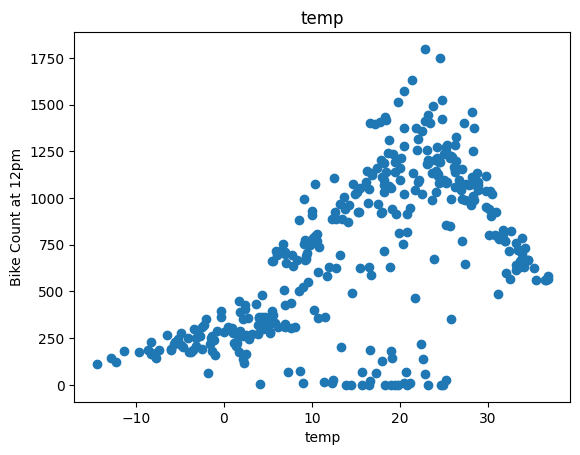

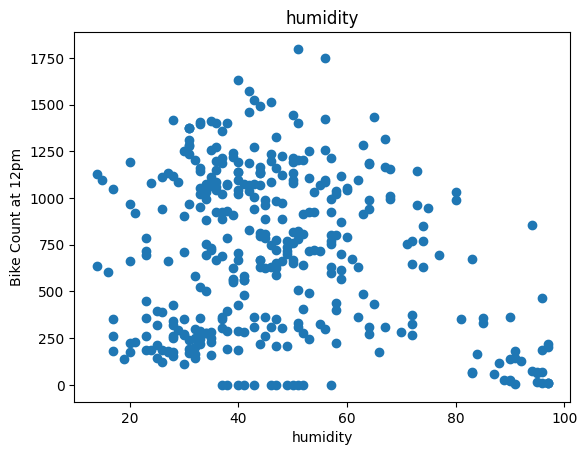

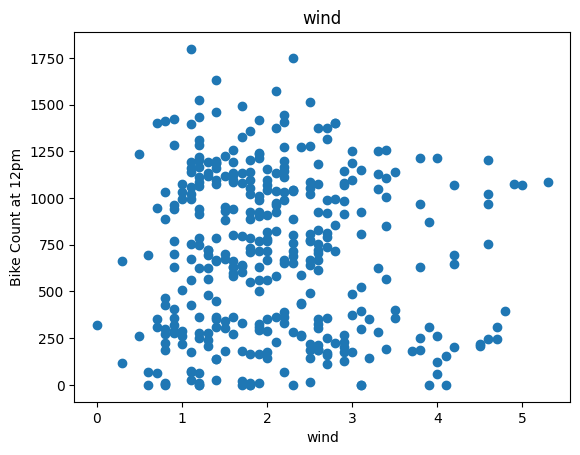

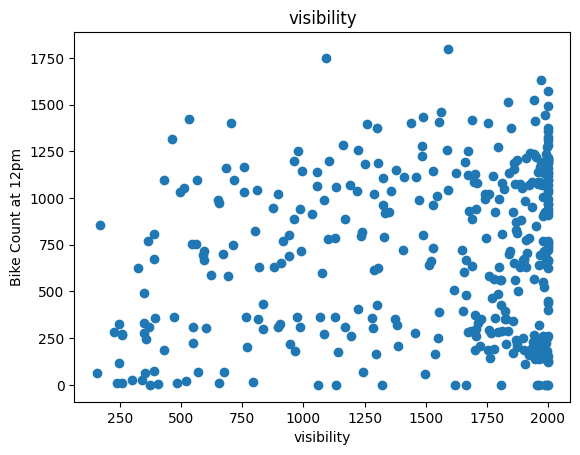

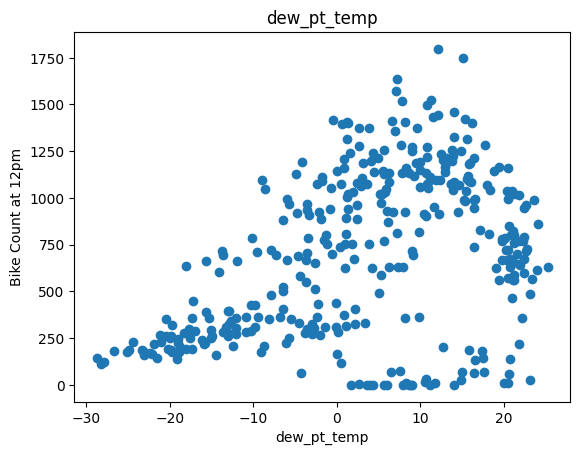

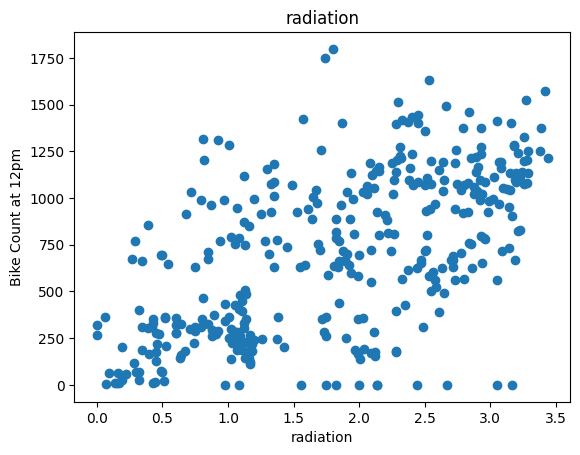

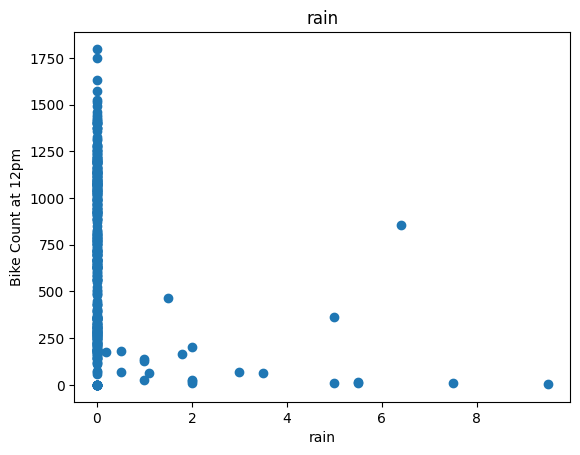

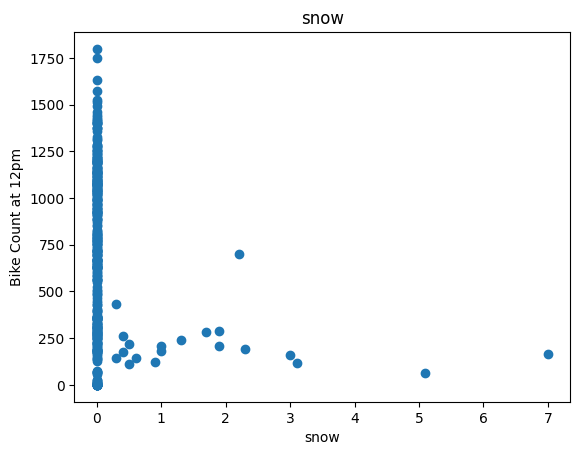

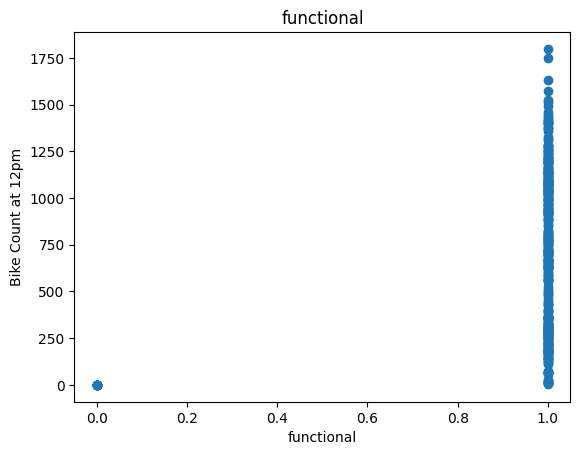

In [6]:
for label in df.columns[2:]:
    plt.scatter(df[label], df["bike_count"])
    plt.title(label)
    plt.ylabel("Bike Count at 12pm")
    plt.xlabel(label)
    plt.show()

In [7]:
df = df.drop(["wind", "visibility", "functional"], axis=1)
df.head()

,bike_count,hour,temp,humidity,dew_pt_temp,radiation,rain,snow
12,449,12,1.7,23,-17.2,1.11,0.0,0.0
36,479,12,4.3,41,-7.8,1.09,0.0,0.0
60,333,12,5.8,85,3.4,0.43,0.0,0.0
84,393,12,-0.3,38,-12.9,1.11,0.0,0.0
108,321,12,-2.3,25,-19.7,0.00,0.0,0.0


# train/validate/test datasets

In [8]:
train_arr, valid_arr, test_arr = np.split(df.sample(frac=1), [int(0.6 * len(df)), int(0.8 * len(df))])

train, valid, test = ((pd.DataFrame(arr, columns=df.columns)) for arr in [train_arr, valid_arr, test_arr])
train.head()

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


,bike_count,hour,temp,humidity,dew_pt_temp,radiation,rain,snow
60,333,12,5.8,85,3.4,0.43,0.0,0.0
5220,1216,12,25.7,57,16.5,2.32,0.0,0.0
4020,467,12,21.7,96,21.0,0.81,1.5,0.0
6444,1070,12,28.9,42,14.6,2.50,0.0,0.0
4740,1525,12,24.8,43,11.3,3.27,0.0,0.0


In [9]:
def get_xy(dataframe, ylabel, xlabels=None):
    dataframe = copy.deepcopy(dataframe)
    if xlabels is None:
        X = dataframe[[c for c in dataframe.columns if c != ylabel]].values
    else:
        if len(xlabels) == 1:
            X = dataframe[xlabels[0]].values.reshape(-1, 1)
        else:
            X = dataframe[xlabels].values
    
    y = dataframe[ylabel].values.reshape(-1, 1)
    data = np.hstack((X, y))
    
    return data, X, y

# Linear Regression

In [10]:
_, x_train_temp, y_train_temp = get_xy(train, "bike_count", xlabels=["temp"])
_, x_valid_temp, y_valid_temp = get_xy(valid, "bike_count", xlabels=["temp"])
_, x_test_temp, y_test_temp = get_xy(test, "bike_count", xlabels=["temp"])

In [11]:
temp_reg = LinearRegression()
temp_reg.fit(x_train_temp, y_train_temp)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
temp_reg.score(x_test_temp, y_test_temp)

0.35935555355764326

The floating-point number above indicates the association between x and y. The closer the number gets to 1, the more correlated the variables are.

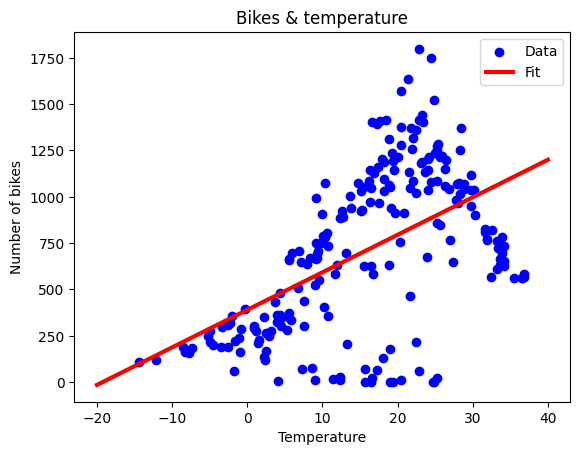

In [13]:
plt.scatter(x_train_temp, y_train_temp, label="Data", color="blue")
x = np.linspace(-20, 40, 100).reshape(-1, 1)

plt.plot(x, temp_reg.predict(x), label="Fit", color="red", linewidth=3)
plt.legend()
plt.title("Bikes & temperature")
plt.ylabel("Number of bikes")
plt.xlabel("Temperature")
plt.show()

# Multiple Linear Regression

In [14]:
_, x_train_all, y_train_all = get_xy(train, "bike_count")
_, x_valid_all, y_valid_all = get_xy(valid, "bike_count")
_, x_test_all, y_test_all = get_xy(test, "bike_count")

In [15]:
all_reg = LinearRegression()
all_reg.fit(x_train_all, y_train_all)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
all_reg.score(x_test_all, y_test_all)

0.41738522597407335

# Regression with Neural Network

In [17]:
temp_normalizer = tf.keras.layers.Normalization(axis=None)
temp_normalizer.adapt(x_train_temp.reshape(-1, 1))

In [18]:
temp_nn_model = tf.keras.Sequential()
temp_nn_model.add(temp_normalizer)
temp_nn_model.add(tf.keras.layers.Dense(1))

In [19]:
loss = tf.keras.losses.MeanSquaredError(reduction="sum_over_batch_size")
temp_nn_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate= 0.1), loss=loss)

In [20]:
history = temp_nn_model.fit(
    x_train_temp.reshape(-1, 1), 
    y_train_temp, 
    epochs=1000, 
    validation_data=(x_valid_temp, y_valid_temp)
) 

Epoch 1/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 700988.9375 - val_loss: 607050.0625
Epoch 2/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 699711.9375 - val_loss: 605804.2500
Epoch 3/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 698428.8125 - val_loss: 604559.7500
Epoch 4/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 697109.6250 - val_loss: 603336.0000
Epoch 5/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 695822.3125 - val_loss: 602108.4375
Epoch 6/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 694557.0000 - val_loss: 600873.8125
Epoch 7/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 693276.9375 - val_loss: 599643.9375
Epoch 8/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 691997.5000 - val_loss: 598417.5000
Epoch 9/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 690726.0000 - val_loss: 597194.6875
Epoch 10/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 689434.4375 - val_loss: 595987.2500
Epoch 11/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss:

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 624579.3125 - val_loss: 534122.8750
Epoch 65/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 623432.0625 - val_loss: 533045.7500
Epoch 66/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 622309.8750 - val_loss: 531964.1875
Epoch 67/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 621184.1250 - val_loss: 530883.6875
Epoch 68/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 620021.6250 - val_loss: 529828.5000
Epoch 69/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 618915.4375 - val_loss: 528758.8750
Epoch 70/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 617820.6875 - val_loss: 527674.8750
Epoch 71/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 616642.9375 - val_loss: 526629.1875
Epoch 72/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 615542.6250 - val_loss: 525574.0000
Epoch 73/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 614448.1250 - val_loss: 524507.3125
Epoch 74/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 61332

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 557500.9375 - val_loss: 470619.8750
Epoch 128/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 556508.6250 - val_loss: 469677.0000
Epoch 129/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 555504.8750 - val_loss: 468738.7500
Epoch 130/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 554520.5625 - val_loss: 467800.1250
Epoch 131/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 553540.0625 - val_loss: 466860.8125
Epoch 132/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 552536.1875 - val_loss: 465934.7812
Epoch 133/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 551542.6250 - val_loss: 465017.2500
Epoch 134/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 550545.8125 - val_loss: 464110.6250
Epoch 135/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 549608.3125 - val_loss: 463177.2500
Epoch 136/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 548624.3750 - val_loss: 462251.6250
Epoch 137/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - l

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 498611.0312 - val_loss: 415309.1250
Epoch 191/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 497777.0625 - val_loss: 414477.3438
Epoch 192/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 496897.7500 - val_loss: 413654.2188
Epoch 193/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 496017.9688 - val_loss: 412839.4688
Epoch 194/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 495129.3438 - val_loss: 412038.1875
Epoch 195/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 494295.3125 - val_loss: 411216.6562
Epoch 196/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 493406.2812 - val_loss: 410411.0625
Epoch 197/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 492536.9062 - val_loss: 409610.9375
Epoch 198/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 491687.0000 - val_loss: 408805.1562
Epoch 199/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 490846.4062 - val_loss: 407991.1875
Epoch 200/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - l

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 446884.6875 - val_loss: 366977.3125
Epoch 254/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 446137.0312 - val_loss: 366247.7500
Epoch 255/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 445359.3750 - val_loss: 365526.7812
Epoch 256/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 444565.1250 - val_loss: 364826.3438
Epoch 257/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 443820.1250 - val_loss: 364113.7500
Epoch 258/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 443067.0625 - val_loss: 363398.7812
Epoch 259/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 442282.4375 - val_loss: 362698.4688
Epoch 260/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 441535.3438 - val_loss: 361990.1250
Epoch 261/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 440790.9688 - val_loss: 361275.0000
Epoch 262/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 440010.2188 - val_loss: 360576.5938
Epoch 263/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - l

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 401342.8438 - val_loss: 324633.9688
Epoch 317/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 400651.8750 - val_loss: 324007.0000
Epoch 318/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 399997.6250 - val_loss: 323365.8750
Epoch 319/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 399305.0312 - val_loss: 322741.9375
Epoch 320/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 398643.5938 - val_loss: 322112.0312
Epoch 321/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 397937.6875 - val_loss: 321503.1250
Epoch 322/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 397295.7188 - val_loss: 320877.7500
Epoch 323/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 396610.3750 - val_loss: 320261.6562
Epoch 324/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 395949.8750 - val_loss: 319640.6562
Epoch 325/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 395304.8438 - val_loss: 319008.9688
Epoch 326/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - l

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 361226.1250 - val_loss: 287452.3438
Epoch 380/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 360616.9375 - val_loss: 286896.6250
Epoch 381/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 360003.5938 - val_loss: 286351.2500
Epoch 382/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 359415.8438 - val_loss: 285802.4688
Epoch 383/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 358829.6250 - val_loss: 285251.7812
Epoch 384/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 358225.5000 - val_loss: 284706.2812
Epoch 385/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 357639.7812 - val_loss: 284157.5938
Epoch 386/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 357056.8750 - val_loss: 283606.3438
Epoch 387/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 356465.1562 - val_loss: 283059.4375
Epoch 388/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 355873.0625 - val_loss: 282518.5312
Epoch 389/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - l

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 325832.0625 - val_loss: 254709.0156
Epoch 443/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 325282.4688 - val_loss: 254227.7031
Epoch 444/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 324764.9062 - val_loss: 253739.2812
Epoch 445/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 324233.7188 - val_loss: 253252.7656
Epoch 446/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 323728.6562 - val_loss: 252756.3594
Epoch 447/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 323185.8125 - val_loss: 252273.9219
Epoch 448/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 322661.8750 - val_loss: 251791.8125
Epoch 449/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 322145.6875 - val_loss: 251308.4375
Epoch 450/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 321627.5000 - val_loss: 250824.7656
Epoch 451/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 321098.5625 - val_loss: 250348.1875
Epoch 452/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - l

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 294538.9375 - val_loss: 225767.9062
Epoch 506/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 294088.5625 - val_loss: 225333.7500
Epoch 507/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 293619.2500 - val_loss: 224903.7656
Epoch 508/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 293155.3750 - val_loss: 224476.7188
Epoch 509/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 292692.2812 - val_loss: 224052.2656
Epoch 510/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 292236.8438 - val_loss: 223623.5625
Epoch 511/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 291785.0312 - val_loss: 223192.0781
Epoch 512/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 291306.3438 - val_loss: 222771.6094
Epoch 513/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 290865.7500 - val_loss: 222340.0625
Epoch 514/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 290388.4688 - val_loss: 221920.3906
Epoch 515/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - l

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 267018.5938 - val_loss: 200239.7969
Epoch 569/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 266600.7188 - val_loss: 199861.2031
Epoch 570/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 266191.1875 - val_loss: 199482.0625
Epoch 571/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 265783.2188 - val_loss: 199106.1094
Epoch 572/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 265382.6875 - val_loss: 198727.1094
Epoch 573/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 264965.3438 - val_loss: 198358.1406
Epoch 574/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 264560.1250 - val_loss: 197987.7500
Epoch 575/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 264173.5312 - val_loss: 197609.1250
Epoch 576/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 263768.8125 - val_loss: 197229.6719
Epoch 577/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 263361.4688 - val_loss: 196853.0156
Epoch 578/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - l

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 242803.3281 - val_loss: 177800.4219
Epoch 632/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 242452.0938 - val_loss: 177466.0625
Epoch 633/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 242091.8125 - val_loss: 177134.0000
Epoch 634/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 241739.9062 - val_loss: 176800.5938
Epoch 635/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 241379.2500 - val_loss: 176469.0156
Epoch 636/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 241028.1719 - val_loss: 176137.7031
Epoch 637/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 240664.4688 - val_loss: 175809.9062
Epoch 638/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 240312.9062 - val_loss: 175482.7188
Epoch 639/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 239955.0000 - val_loss: 175157.4062
Epoch 640/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 239606.4062 - val_loss: 174831.9375
Epoch 641/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - l

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 221672.4062 - val_loss: 158223.6094
Epoch 695/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 221368.0938 - val_loss: 157929.5156
Epoch 696/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 221051.1094 - val_loss: 157638.8594
Epoch 697/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 220741.8125 - val_loss: 157347.4688
Epoch 698/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 220421.9219 - val_loss: 157065.0625
Epoch 699/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 220117.9062 - val_loss: 156782.5938
Epoch 700/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 219805.9375 - val_loss: 156501.5000
Epoch 701/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 219515.1406 - val_loss: 156214.1719
Epoch 702/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 219219.4844 - val_loss: 155920.5312
Epoch 703/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 218885.0938 - val_loss: 155643.3906
Epoch 704/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - l

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 203427.8750 - val_loss: 141385.0312
Epoch 758/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 203168.7344 - val_loss: 141139.5156
Epoch 759/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 202910.0312 - val_loss: 140891.2969
Epoch 760/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 202639.0000 - val_loss: 140646.8750
Epoch 761/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 202384.0781 - val_loss: 140395.3906
Epoch 762/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 202102.5625 - val_loss: 140155.0625
Epoch 763/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 201841.1094 - val_loss: 139914.3594
Epoch 764/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 201585.0938 - val_loss: 139673.4844
Epoch 765/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 201318.5312 - val_loss: 139430.7188
Epoch 766/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 201052.0781 - val_loss: 139191.6875
Epoch 767/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - l

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 187902.9062 - val_loss: 127141.5078
Epoch 821/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 187665.0000 - val_loss: 126941.3281
Epoch 822/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 187456.4062 - val_loss: 126732.9453
Epoch 823/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 187234.8281 - val_loss: 126521.5078
Epoch 824/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 186988.2031 - val_loss: 126322.9453
Epoch 825/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 186787.6094 - val_loss: 126114.0391
Epoch 826/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 186549.1875 - val_loss: 125912.1484
Epoch 827/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 186336.5781 - val_loss: 125708.5078
Epoch 828/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 186107.3594 - val_loss: 125509.6016
Epoch 829/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 185894.0781 - val_loss: 125309.3125
Epoch 830/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - l

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 174925.4375 - val_loss: 115389.0156
Epoch 884/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 174748.7500 - val_loss: 115218.8359
Epoch 885/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 174549.7344 - val_loss: 115054.5859
Epoch 886/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 174383.1562 - val_loss: 114881.8125
Epoch 887/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 174184.9688 - val_loss: 114717.1641
Epoch 888/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 173999.8906 - val_loss: 114555.6172
Epoch 889/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 173825.0781 - val_loss: 114389.0312
Epoch 890/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 173637.8750 - val_loss: 114227.0391
Epoch 891/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 173460.8906 - val_loss: 114064.5078
Epoch 892/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 173278.7031 - val_loss: 113901.3125
Epoch 893/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - l

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 164332.5312 - val_loss: 105928.3047
Epoch 947/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 164184.6406 - val_loss: 105797.0859
Epoch 948/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 164025.5781 - val_loss: 105669.9453
Epoch 949/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 163882.1406 - val_loss: 105540.0312
Epoch 950/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 163745.3750 - val_loss: 105404.0938
Epoch 951/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 163588.2500 - val_loss: 105274.7188
Epoch 952/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 163439.3125 - val_loss: 105147.0000
Epoch 953/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 163290.8750 - val_loss: 105021.1562
Epoch 954/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 163153.6562 - val_loss: 104889.3906
Epoch 955/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 163003.0938 - val_loss: 104761.2500
Epoch 956/1000
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - l

In [21]:
def plot_loss(history):
    plt.plot(history.history['loss'], label='loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Binary Crossentropy')
    plt.legend()
    plt.grid(True)
    plt.show()
    
def plot_accuracy(history):
    plt.plot(history.history['accuracy'], label='accuracy')
    plt.plot(history.history['val_accuracy'], label='val_accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

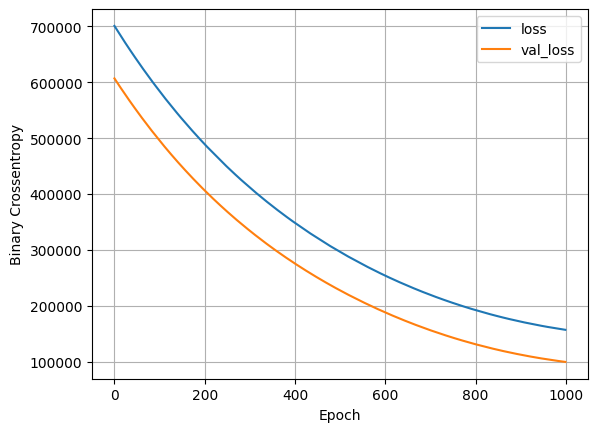

In [22]:
plot_loss(history)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


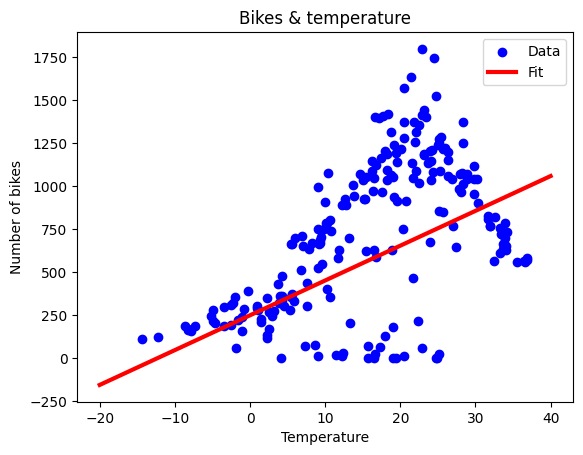

In [23]:
plt.scatter(x_train_temp, y_train_temp, label="Data", color="blue")
x = np.linspace(-20, 40, 100).reshape(-1, 1)

plt.plot(x, temp_nn_model.predict(x), label="Fit", color="red", linewidth=3)
plt.legend()
plt.title("Bikes & temperature")
plt.ylabel("Number of bikes")
plt.xlabel("Temperature")
plt.show()

In [29]:
nn_model = tf.keras.Sequential()
nn_model.add(temp_normalizer)
nn_model.add(tf.keras.layers.Dense(32, activation="relu"))
nn_model.add(tf.keras.layers.Dense(32, activation="relu"))
nn_model.add(tf.keras.layers.Dense(1, activation="relu"))

loss = tf.keras.losses.MeanSquaredError(reduction="sum_over_batch_size")
nn_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate= 0.001), loss=loss)

In [30]:
history = nn_model.fit(
    x_train_temp.reshape(-1, 1),
    y_train_temp,
    epochs=100,
    validation_data=(x_valid_temp, y_valid_temp)
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 701706.3750 - val_loss: 608393.1250
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 701595.0625 - val_loss: 608242.1875
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 701444.6875 - val_loss: 608063.6875
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 701269.1250 - val_loss: 607857.6250
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 701065.0625 - val_loss: 607620.6875
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 700828.8750 - val_loss: 607345.2500
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 700548.0625 - val_loss: 607029.6875
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 700228.0000 - val_loss: 606658.5000
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 699841.1875 - val_loss: 606212.2500
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 699373.5625 - val_loss: 605677.1875
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 698834.875

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 281175.4375 - val_loss: 203144.7969
Epoch 66/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 270509.1562 - val_loss: 193143.4219
Epoch 67/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 260262.8906 - val_loss: 183500.7656
Epoch 68/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 250302.5000 - val_loss: 174408.8125
Epoch 69/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 240103.3281 - val_loss: 166275.0156
Epoch 70/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 231713.3281 - val_loss: 158318.8281
Epoch 71/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 222785.9531 - val_loss: 151195.5312
Epoch 72/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 215264.7500 - val_loss: 144384.6094
Epoch 73/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 207914.0156 - val_loss: 138136.6250
Epoch 74/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 201858.2500 - val_loss: 132106.3281
Epoch 75/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 194790.4219 - v

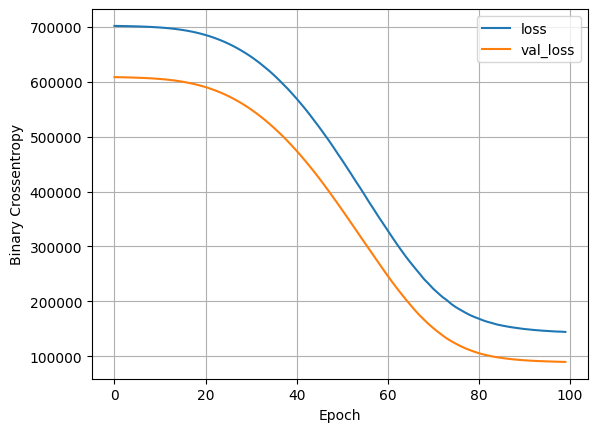

In [31]:
plot_loss(history)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


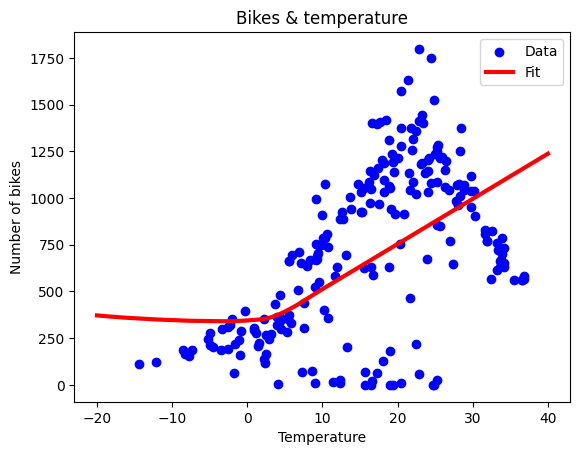

In [32]:
plt.scatter(x_train_temp, y_train_temp, label="Data", color="blue")
x = np.linspace(-20, 40, 100).reshape(-1, 1)

plt.plot(x, nn_model.predict(x), label="Fit", color="red", linewidth=3)
plt.legend()
plt.title("Bikes & temperature")
plt.ylabel("Number of bikes")
plt.xlabel("Temperature")
plt.show()